# EDA về GDP, thất nghiệp và lạm phát ở Việt Nam

Notebook này đi theo đúng thứ tự phân tích trước, đánh giá sau. Mục tiêu là nhìn nhanh chất lượng dữ liệu, xu hướng dài hạn, quan hệ giữa các biến, rồi mới chuyển sang phần mô hình hóa ở notebook regression.

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'processed' / 'merged_dataset.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate data/processed/merged_dataset.csv')

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analysis.macro_analysis import MACRO_COLUMNS, filter_year_range, load_macro_dataset

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.float_format', '{:,.3f}'.format)

In [38]:
df = load_macro_dataset()
df = filter_year_range(df, start_year=1996, end_year=2024)
df['labor_force_millions'] = df['labor_force'] / 1_000_000

analysis_columns = ['year', *MACRO_COLUMNS, 'labor_force_millions']
display(df[analysis_columns].head())
print(f'Dataset shape: {df.shape}')
print('Years covered:', int(df['year'].min()), '-', int(df['year'].max()))
display(df[analysis_columns].describe().T.round(3))

missing_counts = df[analysis_columns].isna().sum().sort_values(ascending=False)
display(missing_counts.to_frame(name='missing_values'))

,year,gdp_growth,unemployment,inflation_cpi,exports_percent_gdp,fdi_percent_gdp,labor_force,labor_force_millions
0,1996,9.340,1.930,5.675,40.868,9.713,"36,468,498.000",36.468
1,1997,8.152,2.870,3.210,43.103,8.270,"37,016,863.000",37.017
2,1998,5.764,2.290,7.266,44.848,6.141,"37,710,949.000",37.711
3,1999,4.774,2.330,4.117,49.966,4.923,"38,384,112.000",38.384
4,2000,6.787,2.260,-1.710,53.921,4.164,"38,790,735.000",38.791


Dataset shape: (29, 30)
Years covered: 1996 - 2024


,count,mean,std,min,25%,50%,75%,max
year,29.000,"2,010.000",8.515,"1,996.000","2,003.000","2,010.000","2,017.000","2,024.000"
gdp_growth,29.000,6.426,1.447,2.554,5.662,6.690,7.130,9.340
unemployment,29.000,1.867,0.483,0.999,1.602,1.889,2.140,2.870
inflation_cpi,29.000,5.611,5.087,-1.710,3.210,3.831,7.418,23.115
exports_percent_gdp,29.000,67.437,15.233,40.868,55.062,66.800,81.763,93.850
fdi_percent_gdp,29.000,5.149,1.792,3.390,4.164,4.329,5.011,9.713
labor_force,29.000,"48,413,227.966","7,165,150.095","36,468,498.000","41,746,162.000","50,303,014.000","55,149,609.000","56,703,936.000"
labor_force_millions,29.000,48.413,7.165,36.468,41.746,50.303,55.150,56.704


,missing_values
year,0
gdp_growth,0
unemployment,0
inflation_cpi,0
exports_percent_gdp,0
fdi_percent_gdp,0
labor_force,0
labor_force_millions,0


## 1. Phân tích EDA

Phần này tập trung vào 3 câu hỏi: xu hướng của từng biến thay đổi thế nào theo thời gian, mối liên hệ giữa GDP growth và thất nghiệp có thật sự rõ không, và cấu trúc tương quan chung của bộ biến có ổn định không.

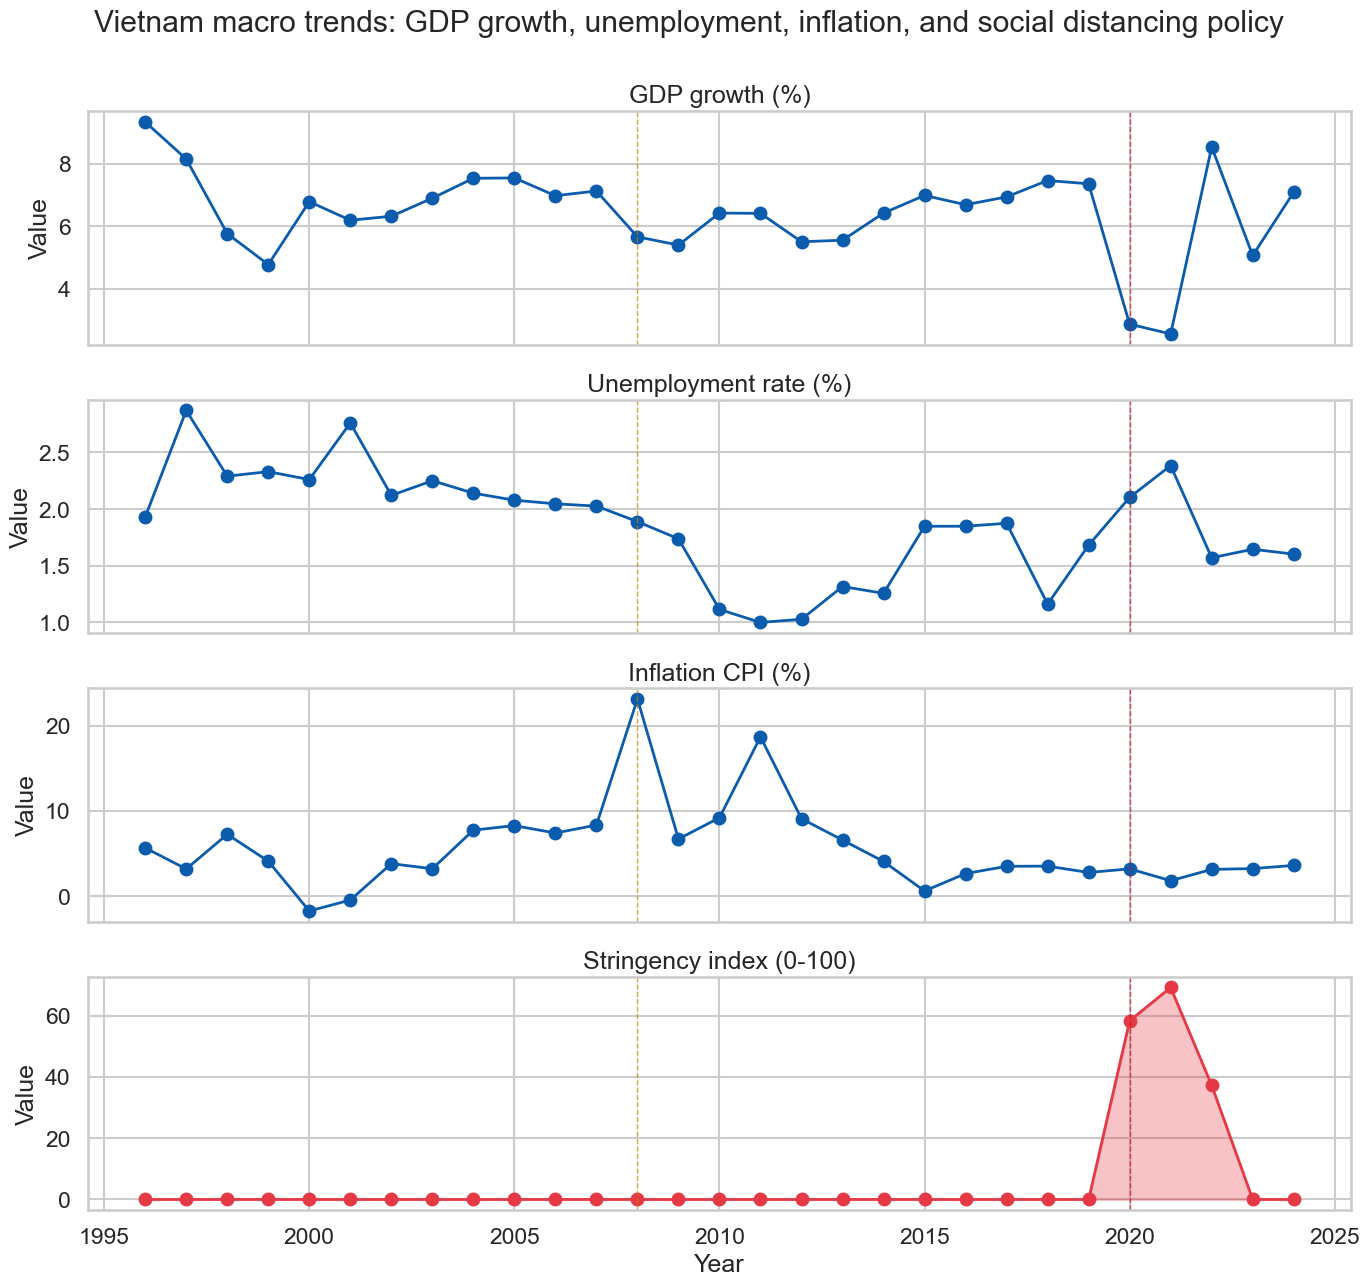

In [39]:
trend_variables = ['gdp_growth', 'unemployment', 'inflation_cpi', 'stringency_index']
trend_titles = {
    'gdp_growth': 'GDP growth (%)',
    'unemployment': 'Unemployment rate (%)',
    'inflation_cpi': 'Inflation CPI (%)',
    'stringency_index': 'Stringency index (0-100)',
}

fig, axes = plt.subplots(len(trend_variables), 1, figsize=(14, 13), sharex=True)
for axis, column in zip(axes, trend_variables):
    valid = df[['year', column]].dropna()
    if column == 'stringency_index':
        axis.fill_between(valid['year'], valid[column], alpha=0.3, color='#E63946')
        axis.plot(valid['year'], valid[column], marker='o', linewidth=2, color='#E63946')
    else:
        axis.plot(valid['year'], valid[column], marker='o', linewidth=2, color='#0B5CAD')
    axis.axvline(2008, color='#C77D00', linestyle='--', linewidth=1, alpha=0.7)
    axis.axvline(2020, color='#C1121F', linestyle='--', linewidth=1, alpha=0.7)
    axis.set_title(trend_titles[column])
    axis.set_ylabel('Value')

axes[-1].set_xlabel('Year')
fig.suptitle('Vietnam macro trends: GDP growth, unemployment, inflation, and social distancing policy', y=0.995)
fig.tight_layout()

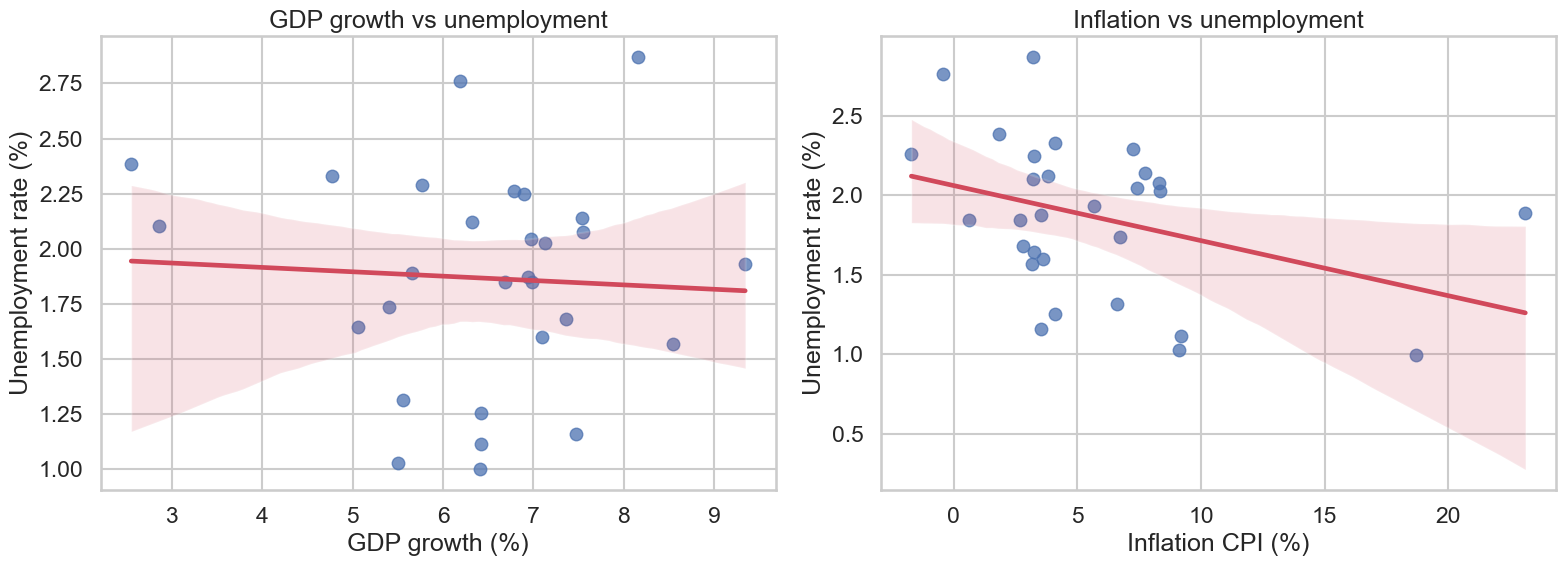

In [40]:
pair_columns = ['gdp_growth', 'unemployment', 'inflation_cpi']
pair_frame = df[pair_columns].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.regplot(data=pair_frame, x='gdp_growth', y='unemployment', ax=axes[0], scatter_kws={'alpha': 0.75}, line_kws={'color': '#D1495B'})
axes[0].set_title('GDP growth vs unemployment')
axes[0].set_xlabel('GDP growth (%)')
axes[0].set_ylabel('Unemployment rate (%)')

sns.regplot(data=pair_frame, x='inflation_cpi', y='unemployment', ax=axes[1], scatter_kws={'alpha': 0.75}, line_kws={'color': '#D1495B'})
axes[1].set_title('Inflation vs unemployment')
axes[1].set_xlabel('Inflation CPI (%)')
axes[1].set_ylabel('Unemployment rate (%)')

fig.tight_layout()

Correlations with unemployment:


,corr_with_unemployment
unemployment,1.000
stringency_index,0.161
fdi_percent_gdp,0.146
gdp_growth,-0.059
exports_percent_gdp,-0.326
inflation_cpi,-0.365
labor_force,-0.635



Correlations with stringency_index (social distancing policy):


,corr_with_stringency_index
stringency_index,1.000
exports_percent_gdp,0.505
labor_force,0.332
unemployment,0.161
fdi_percent_gdp,-0.143
inflation_cpi,-0.197
gdp_growth,-0.558


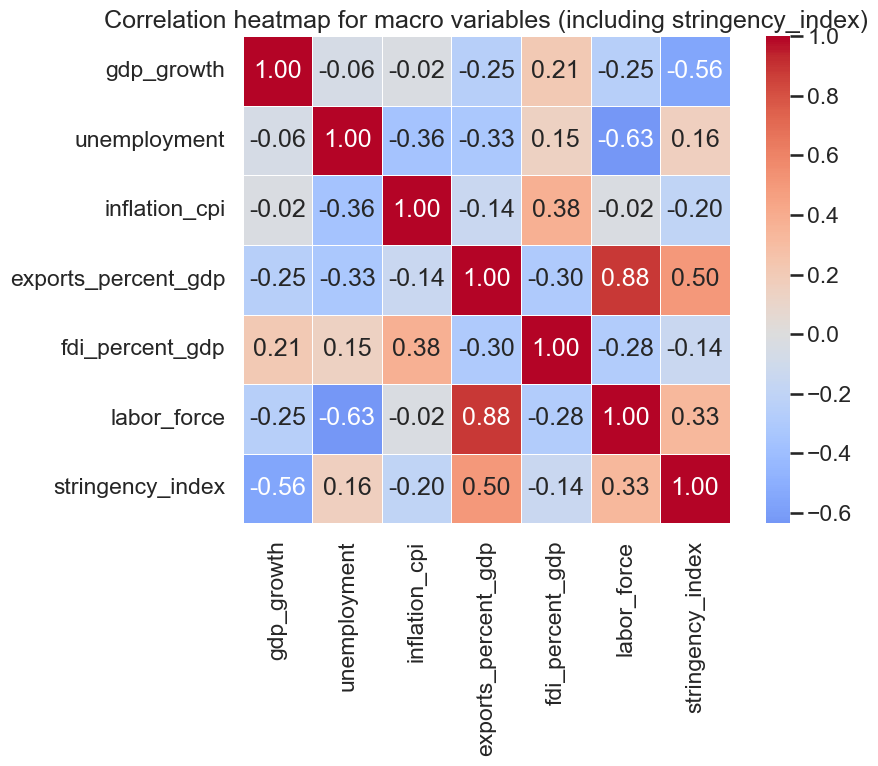

In [41]:
corr_columns = ['gdp_growth', 'unemployment', 'inflation_cpi', 'exports_percent_gdp', 'fdi_percent_gdp', 'labor_force', 'stringency_index']
corr_frame = df[corr_columns].dropna()
corr_matrix = corr_frame.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation heatmap for macro variables (including stringency_index)')
plt.tight_layout()

print('Correlations with unemployment:')
display(corr_matrix['unemployment'].sort_values(ascending=False).to_frame(name='corr_with_unemployment'))
print('\nCorrelations with stringency_index (social distancing policy):')
display(corr_matrix['stringency_index'].sort_values(ascending=False).to_frame(name='corr_with_stringency_index'))

So sánh các giai đoạn trước - trong - sau giãn cách xã hội:


gdp_growth                    unemployment         \
                                  mean median   std count         mean median   
period                                                                          
post_reopening                   6.898  7.091 1.744     3        1.606  1.602   
pre_social_distancing            6.677  6.739 0.993    24        1.869  1.910   
social_distancing_2020_2021      2.710  2.710 0.220     2        2.243  2.243   

                                        inflation_cpi                     
                              std count          mean median   std count  
period                                                                    
post_reopening              0.038     3         3.343  3.253 0.245     3  
pre_social_distancing       0.511    24         6.152  4.896 5.445    24  
social_distancing_2020_2021 0.198     2         2.528  2.528 0.980     2

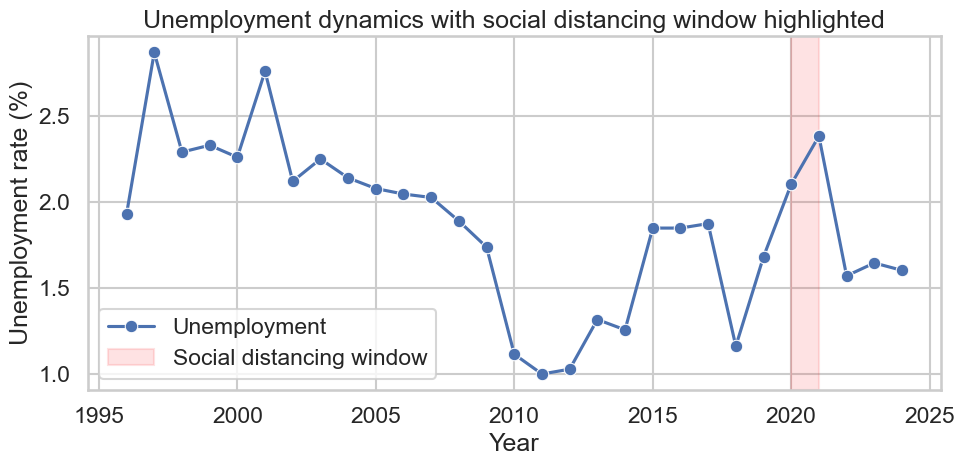

In [42]:
period_frame = df[['year', 'gdp_growth', 'unemployment', 'inflation_cpi']].dropna().copy()

def classify_period(year: int) -> str:
    if year <= 2019:
        return 'pre_social_distancing'
    if year <= 2021:
        return 'social_distancing_2020_2021'
    return 'post_reopening'

period_frame['period'] = period_frame['year'].astype(int).apply(classify_period)

period_summary = (
    period_frame.groupby('period')[['gdp_growth', 'unemployment', 'inflation_cpi']]
    .agg(['mean', 'median', 'std', 'count'])
    .round(3)
    .sort_index()
)

print('So sánh các giai đoạn trước - trong - sau giãn cách xã hội:')
display(period_summary)

plt.figure(figsize=(10, 5))
sns.lineplot(data=period_frame, x='year', y='unemployment', marker='o', label='Unemployment')
plt.axvspan(2020, 2021, color='#F94144', alpha=0.15, label='Social distancing window')
plt.title('Unemployment dynamics with social distancing window highlighted')
plt.ylabel('Unemployment rate (%)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()

## 2. Đánh giá EDA

Kết quả EDA cho thấy bộ dữ liệu có dạng chuỗi thời gian ngắn, còn khoảng gần 30 quan sát sau khi lọc từ năm 1996 đến 2024. Điều này đủ để mô tả xu hướng cơ bản nhưng chưa mạnh cho các mô hình quá nhiều biến. Các cú sốc kinh tế quanh 2008 và 2020 hiện khá rõ trên biểu đồ, vì vậy khi bước sang regression cần lưu ý khả năng cấu trúc dữ liệu thay đổi theo giai đoạn.

Đặc biệt, giai đoạn COVID-19 có các đợt giãn cách xã hội mạnh (nhất là 2020-2021) làm đứt gãy chuỗi cung ứng, thay đổi hành vi tiêu dùng, và dịch chuyển lao động tạm thời. Bảng so sánh giai đoạn trước-trong-sau giãn cách ở cell ngay phía trên giúp định lượng mức thay đổi trung bình của `gdp_growth`, `unemployment`, và `inflation_cpi` thay vì chỉ nhận xét định tính.

Vì vậy quan hệ giữa GDP growth, unemployment và inflation trong giai đoạn giãn cách có thể mang tính bất thường, không đại diện cho trạng thái bình thường của nền kinh tế. Đây là lý do khi sang regression cần đọc kết quả theo bối cảnh chính sách và ưu tiên thêm mô hình động (như VAR) bên cạnh OLS.